# Figure 3b - Percent of total paths that are uphill for each 'strong' model (affinity-only, antigen capture, and competitive capture)

BA.1-only scenarios found:
  Affinity: 1 rows
  Capture: 1 rows
  Competitive: 1 rows

Log10 statistics:
  Affinity:    mean=5.600, SEM=0.094
  Capture:     mean=4.981, SEM=0.130
  Competitive: mean=5.021, SEM=0.171

Total possible paths: 6,227,020,800

Percent of total paths:
  Affinity:    0.00639%
  Capture:     0.00154%
  Competitive: 0.00169%

Figures saved successfully!

Canvas size: 0.5 × 1.25 inches
Total figure size: 1.40 × 2.05 inches
At 2000 DPI: 2800 × 4100 pixels
Summary statistics saved!


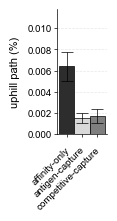

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
import math
import os

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

# Canvas size
CANVAS_WIDTH = 0.5
CANVAS_HEIGHT = 1.25

# Margins (in inches)
LEFT_MARGIN = 0.7
RIGHT_MARGIN = 0.2
TOP_MARGIN = 0.2
BOTTOM_MARGIN = 0.6

# Output DPI
OUTPUT_DPI = 2000

affinity_file = '../../pathway_analysis/affinity_only/strong_data/likelihoods_omi-32_affinity_strong.csv'
capture_file = '../../pathway_analysis/antigen_capture/strong_norm_data/likelihoods_omi-32_capture_strong.csv'
competitive_file = '../../pathway_analysis/competitive_antigen_capture/strong_norm_data/likelihoods_omi-32_competitive_capture_strong.csv'

affinity_df = pd.read_csv(affinity_file)
capture_df = pd.read_csv(capture_file)
competitive_df = pd.read_csv(competitive_file)

# Function to filter for ba1-only scenarios (all 13 mutations are ba1)
def filter_ba1_only(df):
    step_cols = [f'step_{i}' for i in range(1, 14)]
    ba1_mask = (df[step_cols] == 'ba1').all(axis=1)
    return df[ba1_mask]

# Filter each dataframe for ba1-only scenarios
affinity_ba1 = filter_ba1_only(affinity_df)
capture_ba1 = filter_ba1_only(capture_df)
competitive_ba1 = filter_ba1_only(competitive_df)

print(f"BA.1-only scenarios found:")
print(f"  Affinity: {len(affinity_ba1)} rows")
print(f"  Capture: {len(capture_ba1)} rows")
print(f"  Competitive: {len(competitive_ba1)} rows")

# Function to calculate mean and SEM in log10 space (geometric mean) for bootstrap columns
def calculate_log10_stats(df):
    bootstrap_cols = [col for col in df.columns if col.startswith('bootstrap_')]
    bootstrap_values = df[bootstrap_cols].values.flatten()
    
    # Remove zeros/NaN and convert to log10
    bootstrap_values_nonzero = bootstrap_values[bootstrap_values > 0]
    log10_values = np.log10(bootstrap_values_nonzero)
    
    mean_log10 = np.mean(log10_values)
    sem_log10 = stats.sem(log10_values)
    
    return mean_log10, sem_log10

# Calculate statistics for each dataset
affinity_mean, affinity_sem = calculate_log10_stats(affinity_ba1)
capture_mean, capture_sem = calculate_log10_stats(capture_ba1)
competitive_mean, competitive_sem = calculate_log10_stats(competitive_ba1)

print(f"\nLog10 statistics:")
print(f"  Affinity:    mean={affinity_mean:.3f}, SEM={affinity_sem:.3f}")
print(f"  Capture:     mean={capture_mean:.3f}, SEM={capture_sem:.3f}")
print(f"  Competitive: mean={competitive_mean:.3f}, SEM={competitive_sem:.3f}")

# Calculate total paths (13!)
total_paths = math.factorial(13)
print(f"\nTotal possible paths: {total_paths:,}")

# Calculate mean paths and percent of total for each dataset
affinity_paths = 10**affinity_mean
capture_paths = 10**capture_mean
competitive_paths = 10**competitive_mean

affinity_percent = (affinity_paths / total_paths) * 100
capture_percent = (capture_paths / total_paths) * 100
competitive_percent = (competitive_paths / total_paths) * 100

print(f"\nPercent of total paths:")
print(f"  Affinity:    {affinity_percent:.5f}%")
print(f"  Capture:     {capture_percent:.5f}%")
print(f"  Competitive: {competitive_percent:.5f}%")

# Calculate error bars in percent space
affinity_percent_sem = affinity_percent * np.log(10) * affinity_sem
capture_percent_sem = capture_percent * np.log(10) * capture_sem
competitive_percent_sem = competitive_percent * np.log(10) * competitive_sem

# Calculate total figure size
fig_width = LEFT_MARGIN + CANVAS_WIDTH + RIGHT_MARGIN
fig_height = TOP_MARGIN + CANVAS_HEIGHT + BOTTOM_MARGIN

# Create the figure with GridSpec
fig = plt.figure(figsize=(fig_width, fig_height))
gs = GridSpec(1, 1, figure=fig,
              left=LEFT_MARGIN/fig_width,
              right=(LEFT_MARGIN + CANVAS_WIDTH)/fig_width,
              top=1 - TOP_MARGIN/fig_height,
              bottom=BOTTOM_MARGIN/fig_height)

ax = fig.add_subplot(gs[0])

# Data for plotting
x_positions = [0, 0.75, 1.5]
percents = [affinity_percent, capture_percent, competitive_percent]
percent_sems = [affinity_percent_sem, capture_percent_sem, competitive_percent_sem]
labels = ['affinity-only', 'antigen-capture', 'competitive-capture']

# Use gray palette: darkest, lightest, middle
colors = ['#2d2d2d', '#d9d9d9', '#7f7f7f']

# Create bars with error bars
bars = ax.bar(x_positions, percents, yerr=percent_sems,
               color=colors, edgecolor='black', linewidth=0.5,
               capsize=4, error_kw={'linewidth': 0.5, 'capthick':0.5,'ecolor': 'black'},
               width=0.75)

# Set y-axis limits
max_y = max([p + s for p, s in zip(percents, percent_sems)])
ax.set_ylim(0, max_y + 0.004)

# Customize the plot
ax.set_ylabel('')

ax.set_xticks(x_positions)

# Set labels manually with different positions for the third one
for i, (pos, label) in enumerate(zip(x_positions, labels)):
    if i == 3:  
        ax.text(pos + 0.4, -0.001, label, fontsize=7, rotation=45, 
                ha='right', va='top', transform=ax.transData)
    else:
        ax.text(pos +0.2, -0.001, label, fontsize=7, rotation=45, 
                ha='right', va='top', transform=ax.transData)

ax.set_xticklabels([])

# Manually place y-axis label using figure coordinates (0-1 scale)
label_x_position = (LEFT_MARGIN * 0.4) / fig_width

fig.text(label_x_position, 0.6, 'uphill path (%)', 
         fontsize=8, rotation=90, 
         ha='center', va='center')

# Set tick properties
ax.tick_params(axis='y', labelsize=7, pad=2, length=2, width=0.5, direction='out')
ax.tick_params(axis='x', labelsize=7, pad=2, length=2, width=0.5, direction='out')
ax.yaxis.set_tick_params(which='both', labelleft=True, left=True)
ax.xaxis.set_tick_params(which='both', labelbottom=True, bottom=True)

# Customize spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Add grid
ax.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Save the figure
os.makedirs('Figure_3b', exist_ok=True)
plt.savefig('Figure_3b/Figure_3b.png', dpi=OUTPUT_DPI, bbox_inches='tight', transparent=True)
print("\nFigures saved successfully!")

# Print figure size information
print(f'\nCanvas size: {CANVAS_WIDTH} × {CANVAS_HEIGHT} inches')
print(f'Total figure size: {fig_width:.2f} × {fig_height:.2f} inches')
print(f'At {OUTPUT_DPI} DPI: {int(fig_width * OUTPUT_DPI)} × {int(fig_height * OUTPUT_DPI)} pixels')

# Save summary statistics
summary_df = pd.DataFrame({
    'Dataset': labels,
    'Mean_log10_paths': [affinity_mean, capture_mean, competitive_mean],
    'SEM_log10_paths': [affinity_sem, capture_sem, competitive_sem],
    'Mean_paths': [affinity_paths, capture_paths, competitive_paths],
    'Percent_of_total': percents
})
summary_df.to_csv('Figure_3b/ba1_summary_statistics.csv', index=False)
print("Summary statistics saved!")

plt.show()